# End-to-End Plant Disease Classification Pipeline

This notebook contains the complete pipeline for image classification using the PlantVillage dataset.

## Phase 1: Exploratory Data Analysis (EDA) & Setup
Here we map image paths to disease classes, check class distribution, and visualize.

In [6]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2

dataset_dir = r"c:\Users\pravin sharma\Documents\GitHub\KisanMitra\PlantVillage"

# Map image paths to classes
image_paths = []
labels = []
for folder in os.listdir(dataset_dir):
    folder_path = os.path.join(dataset_dir, folder)
    if os.path.isdir(folder_path):
        for img in os.listdir(folder_path):
            if img.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(folder_path, img))
                labels.append(folder)

df = pd.DataFrame({'filepath': image_paths, 'label': labels})
print(f"Total images found: {len(df)}")

Total images found: 20638


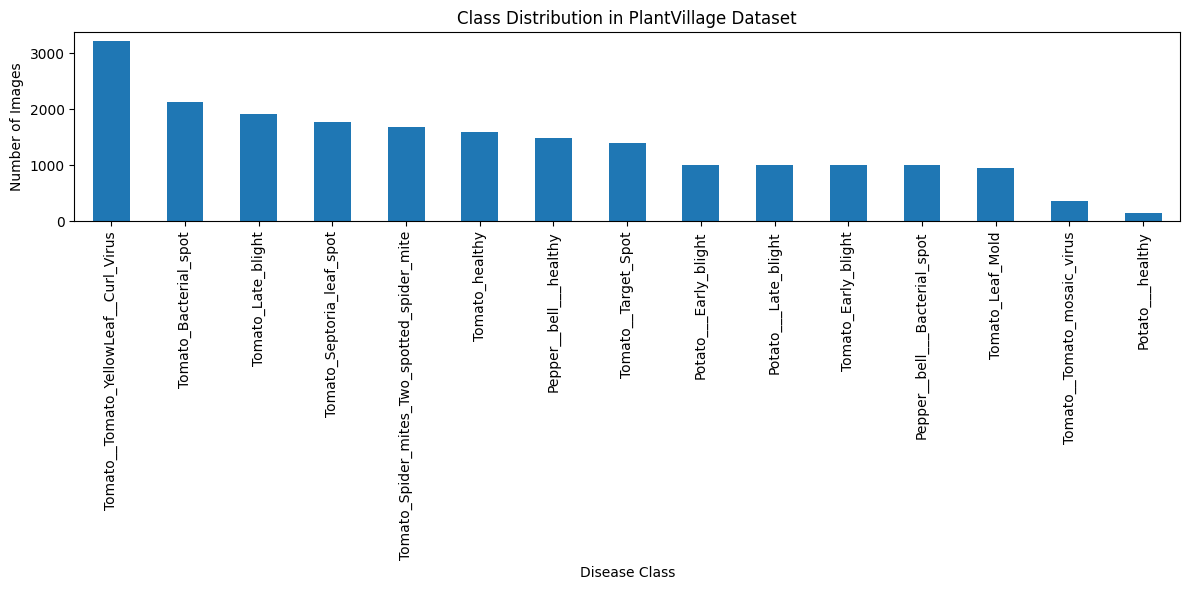

In [7]:
# Class distribution bar chart
class_counts = df['label'].value_counts()
plt.figure(figsize=(12, 6))
class_counts.plot(kind='bar')
plt.title('Class Distribution in PlantVillage Dataset')
plt.xlabel('Disease Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

C:\Users\pravin sharma\AppData\Local\Temp\ipykernel_17432\321732982.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = df.groupby('label').apply(lambda x: x.sample(1)).reset_index(drop=True)


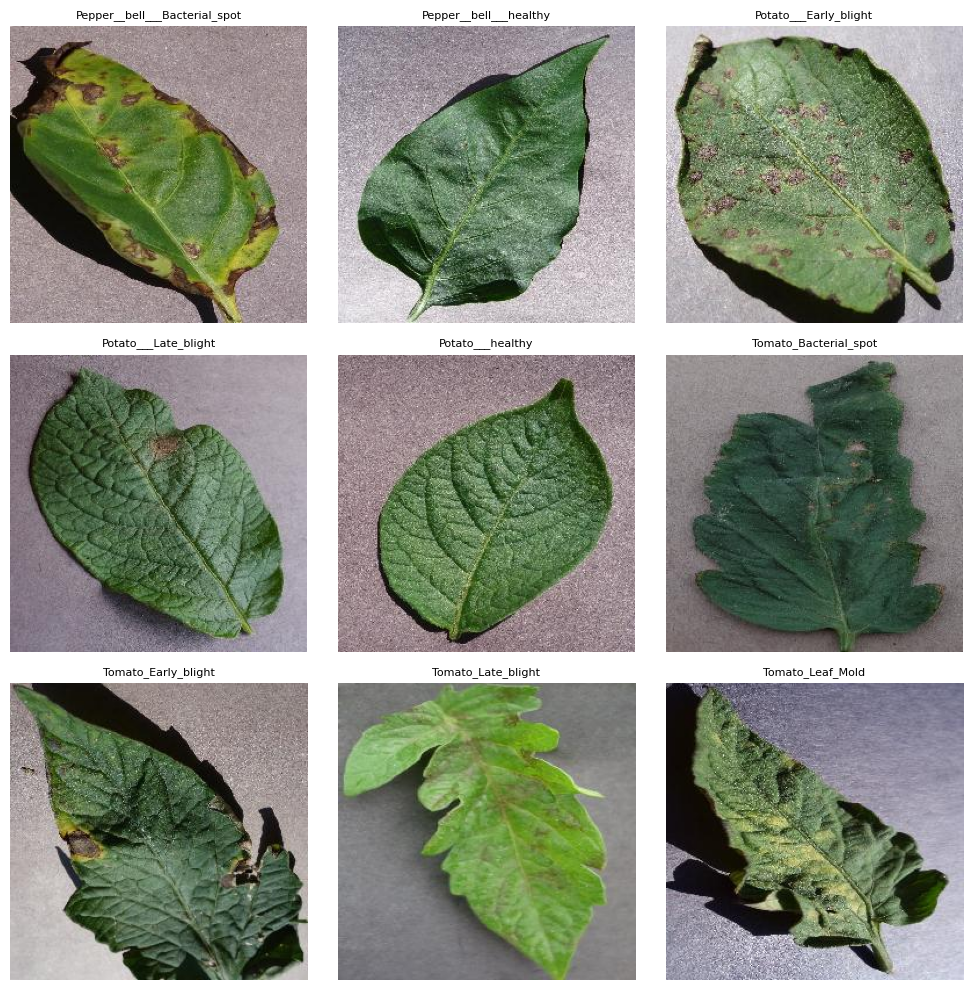

In [8]:
# Sample image grid
plt.figure(figsize=(10, 10))
sample_df = df.groupby('label').apply(lambda x: x.sample(1)).reset_index(drop=True)
for i, row in enumerate(sample_df.head(9).itertuples()):
    plt.subplot(3, 3, i + 1)
    img = cv2.imread(row.filepath)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(row.label, fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

## Phase 2: Stratified Data Splitting & Preprocessing
We use scikit-learn for stratified splitting (70% train, 15% validation, 15% testing).

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# 70% Train, 30% Temp (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    df['filepath'], df['label'], test_size=0.30, stratify=df['label'], random_state=42
)

# Split Temp evenly into 15% Val and 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train size: {len(X_train)} (70%)")
print(f"Validation size: {len(X_val)} (15%)")
print(f"Test size: {len(X_test)} (15%)")

# Calculate class weights
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(range(len(classes)), weights))
print("Class weights calculated successfully.")

Train size: 14446 (70%)
Validation size: 3096 (15%)
Test size: 3096 (15%)
Class weights calculated successfully.


In [10]:
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)
num_classes = len(classes)

def create_dataset(filepaths, labels, batch_size=32, is_training=False):
    dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    def load_and_preprocess(filepath, label):
        img = tf.io.read_file(filepath)
        # FIX: decode_image handles JPG, PNG and WebP — decode_jpeg would crash on PNGs
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, [224, 224])
        img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
        return img, label

    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if is_training:
        # FIX: Buffer raised from 1000 → 5000 (train set = 14,446 images).
        # A buffer of 1000 only shuffles 6.9% of the data at a time, causing
        # biased batches where the model sees the same disease sequences repeatedly.
        dataset = dataset.shuffle(buffer_size=5000, reshuffle_each_iteration=True)

    dataset = dataset.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

train_ds = create_dataset(X_train.values, y_train_enc, is_training=True)
val_ds = create_dataset(X_val.values, y_val_enc)
test_ds = create_dataset(X_test.values, y_test_enc)
print(f'Datasets ready. Train shuffle buffer: 5000 / {len(X_train)} images')


Datasets ready. Train shuffle buffer: 5000 / 14446 images


## Phase 3: Model Architecture (Transfer Learning)
Using MobileNetV2 with an augmentation pipeline inside the model architecture.

In [6]:
from tensorflow.keras import layers, models, applications

# Data Augmentation pipeline
# FIX: Removed RandomContrast(0.2) — plant diseases depend on subtle colour cues
# (e.g. yellow halo vs brown spot). Random contrast destroyed exactly those features,
# causing near-zero recall on colour-sensitive classes like spider mites and mosaic virus.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    # RandomContrast REMOVED intentionally
], name='data_augmentation')

# Transfer learning base
base_model = applications.MobileNetV2(input_shape=(224, 224, 3),
                                       include_top=False,
                                       weights='imagenet')
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)

# FIX: Expanded classifier head — Dense(128) was a severe bottleneck.
# MobileNetV2 produces 1280 features. Squeezing directly to 128 forces the network
# to discard >90% of extracted feature space BEFORE making the 15-class decision.
# New head: 1280 → 512 → 256 → 15 gives the model room to learn complex textures.
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)         # stabilises training of the deeper head
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         655,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 15)                  │           3,855 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,051,087 (11.64 MB)

 Trainable params: 792,079 (3.02 MB)

 Non-trainable params: 2,259,008 (8.62 MB)

## Phase 4: Training & Optimization
Compile and train the model with callbacks.

In [14]:
# import tensorflow_addons as tfa
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# FIX: Add @keras.saving.register_keras_serializable() so Keras can find this
# class when loading the saved model. Without it, load_model() throws:
# TypeError: Could not locate class 'SparseFocalLoss'
@tf.keras.saving.register_keras_serializable(package='KisanMitra')
class SparseFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super().__init__(name='sparse_focal_loss', **kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_true  = tf.cast(y_true, tf.int32)
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1.0)
        one_hot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        ce      = -tf.reduce_sum(one_hot * tf.math.log(y_pred), axis=-1)
        p_t     = tf.reduce_sum(one_hot * y_pred, axis=-1)
        focal_weight = self.alpha * tf.pow(1.0 - p_t, self.gamma)
        return tf.reduce_mean(focal_weight * ce)

    def get_config(self):
        # Required so Keras can serialise/deserialise gamma and alpha
        cfg = super().get_config()
        cfg.update({'gamma': self.gamma, 'alpha': self.alpha})
        return cfg

focal_loss = SparseFocalLoss(gamma=2.0, alpha=0.25)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=focal_loss,
    metrics=['accuracy']
)

callbacks = [
    ModelCheckpoint('best_plant_model.keras', save_best_only=True,
                    monitor='val_accuracy', mode='max', verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

print('=== Phase 1: Warmup (base frozen) ===')
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)


=== Phase 1: Warmup (base frozen) ===
Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.6191 - loss: 0.2332
Epoch 1: val_accuracy improved from None to 0.82558, saving model to best_plant_model.keras

Epoch 1: finished saving model to best_plant_model.keras
452/452 ━━━━━━━━━━━━━━━━━━━━ 217s 458ms/step - accuracy: 0.7062 - loss: 0.1562 - val_accuracy: 0.8256 - val_loss: 0.0723 - learning_rate: 0.0010
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7874 - loss: 0.0954
Epoch 2: val_accuracy improved from 0.82558 to 0.83882, saving model to best_plant_model.keras

Epoch 2: finished saving model to best_plant_model.keras
452/452 ━━━━━━━━━━━━━━━━━━━━ 538s 1s/step - accuracy: 0.7960 - loss: 0.0883 - val_accuracy: 0.8388 - val_loss: 0.0666 - learning_rate: 0.0010
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8145 - loss: 0.0774
Epoch 3: val_accuracy improved from 0.83882 to 0.84432, saving model to best_plant_model.keras

Epoch 3: finished 

In [15]:
# Phase 2: Fine-tuning — unfreeze top 20% of MobileNetV2 layers
base_model.trainable = True
fine_tune_at = int(len(base_model.layers) * 0.8)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f'Fine-tuning from layer {fine_tune_at} / {len(base_model.layers)}')
print(f'Trainable layers: {sum(1 for l in base_model.layers if l.trainable)}')

# Recompile with same focal loss at lower LR for fine-tuning
model.compile(
    loss=focal_loss,
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics=['accuracy']
)

print('=== Phase 2: Fine-tuning (top 20% unfrozen) ===')
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)


Fine-tuning from layer 123 / 154
Trainable layers: 31
=== Phase 2: Fine-tuning (top 20% unfrozen) ===
Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.7524 - loss: 0.1174
Epoch 1: val_accuracy did not improve from 0.87597
452/452 ━━━━━━━━━━━━━━━━━━━━ 277s 576ms/step - accuracy: 0.7857 - loss: 0.0959 - val_accuracy: 0.7494 - val_loss: 0.2197 - learning_rate: 1.0000e-05
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.8251 - loss: 0.0718
Epoch 2: val_accuracy did not improve from 0.87597
452/452 ━━━━━━━━━━━━━━━━━━━━ 283s 620ms/step - accuracy: 0.8364 - loss: 0.0674 - val_accuracy: 0.8178 - val_loss: 0.1160 - learning_rate: 1.0000e-05
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.8537 - loss: 0.0558
Epoch 3: val_accuracy did not improve from 0.87597

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
452/452 ━━━━━━━━━━━━━━━━━━━━ 266s 583ms/step - accuracy: 0.8544 - loss: 0.0547 - val_accuracy: 0.8475 - v

## Phase 5: Evaluation & Inference
Evaluate on unseen 15% Test Set and plot a confusion matrix.

Model loaded successfully.
97/97 ━━━━━━━━━━━━━━━━━━━━ 34s 321ms/step - accuracy: 0.9012 - loss: 0.3309

Test Accuracy : 0.9012
Test Loss     : 0.3309

Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.95      0.95      0.95       149
                     Pepper__bell___healthy       0.97      1.00      0.98       221
                      Potato___Early_blight       0.93      0.98      0.95       150
                       Potato___Late_blight       0.92      0.88      0.90       150
                           Potato___healthy       0.68      0.91      0.78        23
                      Tomato_Bacterial_spot       0.89      0.92      0.91       319
                        Tomato_Early_blight       0.92      0.51      0.65       150
                         Tomato_Late_blight       0.94      0.85      0.89       287
                           Tomato_Leaf_Mold       0.92      

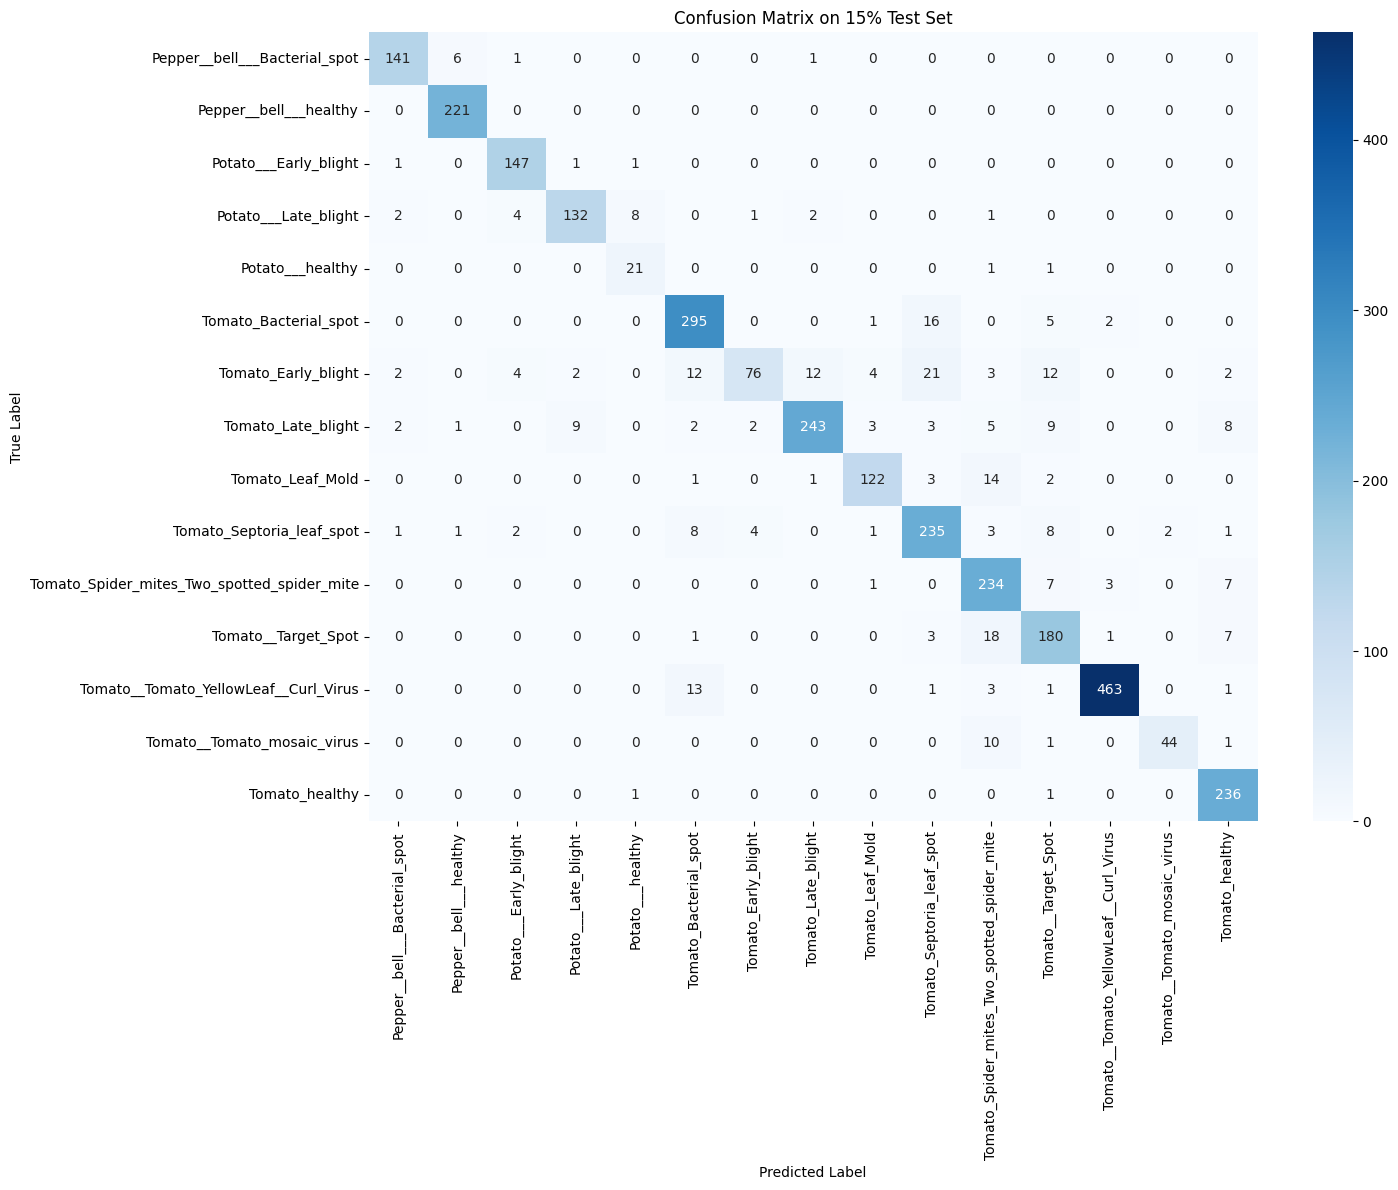

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# FIX: Two-layer defence against the SparseFocalLoss deserialisation error:
#
#  Layer 1 — compile=False: skip recompiling the loss entirely.
#    For inference / evaluation we only need the weights, not the loss.
#    model.evaluate() still works because it recalculates accuracy from predictions.
#
#  Layer 2 — custom_objects: if compile=False is ever removed, Keras will find
#    SparseFocalLoss here instead of crashing with TypeError.
model = tf.keras.models.load_model(
    'best_plant_model.keras',
    compile=False,
    custom_objects={'SparseFocalLoss': SparseFocalLoss}
)
print('Model loaded successfully.')

# Recompile with standard crossentropy just for test-set loss reporting
# (focal loss values are not comparable to crossentropy — use accuracy as the KPI)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f'\nTest Accuracy : {test_acc:.4f}')
print(f'Test Loss     : {test_loss:.4f}')

# Extract true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix on 15% Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [11]:
import joblib
# Save label encoder for prediction script
joblib.dump(le,'label_encoder.pkl')
print("Label encoder saved for standalone script!")

Label encoder saved for standalone script!
